# Image Classification on Fashion-MNIST using CNN
### Comparing a Convolutional Neural Network (CNN) against a fully-connected ANN

**Dataset:** Fashion-MNIST (`fashion_mnist.csv`) — 60,000 grayscale 28×28 clothing images across 10 classes.

## Table of Contents

**Part A — CNN Theory & Concepts**
1. [Introduction to Computer Vision](#intro-cv)
2. [Why Traditional ANN is Not Suitable for Images](#ann-vs-cnn)
3. [Introduction to CNN](#intro-cnn)
4. [CNN Architecture](#cnn-architecture) *(with architecture, convolution & pooling diagrams)*
5. [CNN Hyperparameters](#cnn-hyperparams)
6. [Feature Extraction (Hierarchical Learning)](#feature-extraction) *(with diagram)*
7. [Popular CNN Architectures](#popular-architectures) *(with timeline diagram)*

**Part B — Practical Assignment**
1. [Setup & Imports](#setup-imports)
2. [Data Loading & Exploration](#data-loading)
3. [Data Preprocessing](#data-preprocessing) (normalization, splits, augmentation)
4. [PyTorch Datasets & DataLoaders](#pytorch-datasets)
5. [ANN Model (Baseline)](#ann-model)
6. [CNN Model](#cnn-model)
7. [Training](#training) (Adam / SGD, different LR & batch size experiments)
8. [Evaluation & Visualization](#evaluation-visualization) (Accuracy, Precision, Recall, F1, Confusion Matrix, plots)
9. [ANN vs CNN Performance Comparison](#performance-comparison)
10. [Save Model](#save-model)
11. [Report / Discussion](#report-discussion)


<a id="part-a-theory"></a>


# Part A: CNN Theory & Concepts

This section covers the complete theoretical background for Convolutional Neural Networks (CNNs) as outlined in the course material, before moving into the practical Fashion-MNIST classification project in **Part B**.


<a id="intro-cv"></a>


## 1. Introduction to Computer Vision

### What is Computer Vision?
Computer Vision (CV) is a field of Artificial Intelligence that enables computers to **interpret, analyze, and understand visual information** from the world — images and videos — in a way similar to human vision. It involves acquiring, processing, analyzing, and understanding digital images to extract meaningful, high-level information.

### Image Representation
- A digital image is stored as a **grid (matrix) of pixels**.
- Each pixel holds a numeric intensity value.
- Images are represented as multi-dimensional arrays: **Height × Width × Channels**.

### Pixels and Color Channels (RGB & Grayscale)
- **Grayscale images**: 1 channel, pixel values typically range from 0 (black) to 255 (white). Shape: `H × W × 1`.
- **RGB (color) images**: 3 channels — Red, Green, Blue. Each pixel is a combination of these 3 intensity values. Shape: `H × W × 3`.
- Pixel values are usually normalized (e.g., scaled to `[0, 1]`) before feeding into a neural network.

### Applications of Computer Vision
| Application | Description |
|---|---|
| **Image Classification** | Assigning a label/category to an entire image (e.g., cat vs. dog). |
| **Face Recognition** | Identifying or verifying a person from their face. |
| **Medical Diagnosis** | Detecting tumors, fractures, or diseases from X-rays, MRIs, CT scans. |
| **Self-Driving Cars** | Detecting lanes, pedestrians, traffic signs, and other vehicles. |
| **OCR (Optical Character Recognition)** | Converting images of text into machine-readable text. |
| **Satellite Image Analysis** | Land-use mapping, crop monitoring, disaster assessment. |
| **Industrial Inspection** | Detecting defects on production lines automatically. |


<a id="ann-vs-cnn"></a>


## 2. Why Traditional ANN is Not Suitable for Images

A standard fully connected Artificial Neural Network (ANN) treats every input pixel as an independent feature connected to every neuron in the next layer. This causes several problems when applied to images:

- **High computational cost** — every neuron connects to every pixel, requiring massive amounts of computation.
- **Large number of trainable parameters** — the number of weights explodes very quickly as image size grows.
- **Overfitting** — with so many parameters and comparatively limited data, the model easily memorizes the training set instead of generalizing.
- **Loss of spatial information** — flattening an image into a 1D vector destroys the 2D spatial relationships between neighboring pixels (edges, shapes, textures).
- **Poor scalability for high-resolution images** — the parameter count becomes unmanageable for large images.

### Example
A `224 × 224 × 3` image contains:

$$224 \times 224 \times 3 = 150{,}528 \text{ input features}$$

If this is fully connected to just a single hidden layer of, say, 1,000 neurons, that alone requires:

$$150{,}528 \times 1{,}000 \approx 150 \text{ million parameters}$$

This makes training **computationally expensive** and highly **prone to overfitting** — and this is *before* adding any additional hidden layers. This is exactly the problem CNNs are designed to solve.


<a id="intro-cnn"></a>


## 3. Introduction to CNN

A **Convolutional Neural Network (CNN)** is a specialized type of neural network designed specifically to process grid-like data such as images. Instead of connecting every pixel to every neuron, CNNs exploit the spatial structure of images using the following key ideas:

- **Local Receptive Fields** — each neuron in a convolutional layer only looks at a small local region (patch) of the input, not the entire image, mimicking how the human visual cortex processes information.
- **Weight Sharing** — the same filter (set of weights) is slid across the entire image, drastically reducing the number of parameters compared to a fully connected layer.
- **Sparse Connectivity** — each output value depends only on a small number of inputs (the receptive field), not all of them, reducing computation.
- **Automatic Feature Extraction** — CNNs learn relevant features (edges, textures, shapes) directly from data during training, removing the need for manual feature engineering.
- **Hierarchical Feature Learning** — early layers learn simple features (edges/lines), and deeper layers combine them into increasingly complex, abstract features (parts of objects, whole objects).

Together, these properties make CNNs far more **parameter-efficient**, **spatially aware**, and **scalable** for image data than a plain ANN.


<a id="cnn-architecture"></a>


## 4. CNN Architecture

A typical CNN architecture is built from a stack of the following components, repeated and combined in different ways:

```
Input -> [Convolution -> Activation -> Pooling] x N -> Flatten -> Fully Connected -> Output
```

### 4.1 Input Layer
- Reads the raw input image.
- Defined by its dimensions: **Height × Width × Channels**.
- Example: `224 × 224 × 3` for a standard RGB image, or `28 × 28 × 1` for a grayscale image like Fashion-MNIST.

### 4.2 Convolution Layer
The core building block of a CNN.

- **Convolution operation** — a small filter (kernel) slides over the input image, computing a dot product at each position between the filter weights and the underlying pixel values.
- **Filters (Kernels)** — small learnable matrices (e.g., 3×3, 5×5) that detect specific visual patterns.
- **Feature Maps** — the output produced by applying a filter across the whole image; each filter produces one feature map highlighting where a particular pattern appears.
- **Sliding Window** — the filter moves across the image step by step (governed by *stride*), covering the full input.
- **Shared Weights** — the same filter weights are reused at every spatial location, which massively reduces the parameter count versus a fully connected layer.

**What different filters detect:**
- **Edges** — sharp changes in intensity (horizontal, vertical, diagonal).
- **Corners** — points where two edges meet.
- **Textures** — repeating local patterns (fabric, fur, grain).
- **Shapes** — combinations of edges and corners forming simple geometric forms.

### 4.3 Activation Function
Introduces **non-linearity**, allowing the network to learn complex, non-linear relationships in the data.

- **ReLU (Rectified Linear Unit):** `f(x) = max(0, x)` — sets all negative values to 0, keeps positive values unchanged.
- **Leaky ReLU:** `f(x) = x if x > 0 else α·x` (small α, e.g. 0.01) — allows a small, non-zero gradient when the unit is inactive, avoiding "dead neurons."

**Why activation functions are needed:** Without them, a stack of layers would collapse mathematically into a single linear transformation, no matter how deep — the network could not learn complex patterns.

**Vanishing gradient problem:** With saturating activations like Sigmoid/Tanh, gradients become extremely small as they are backpropagated through many layers, causing early layers to learn very slowly or stop learning entirely.

**Why ReLU is commonly used:** It is computationally cheap, does not saturate for positive inputs (mitigating vanishing gradients), and empirically leads to faster convergence during training.

### 4.4 Pooling Layer
Reduces the spatial size of feature maps while retaining the most important information.

- **Max Pooling** — takes the maximum value in each local window (e.g., 2×2). Captures the strongest activation/feature presence.
- **Average Pooling** — takes the average value in each local window. Provides a smoother, more generalized summary.
- **Global Average Pooling** — averages an entire feature map down to a single value, often used just before the output layer instead of a large fully connected layer.

**Advantages of pooling:**
- Reduces computation and memory usage for subsequent layers.
- Controls overfitting by reducing the number of parameters.
- Preserves the most important (dominant) features while discarding redundant detail.
- Provides a degree of translation invariance (small shifts in the input don't change the pooled output much).

### 4.5 Flatten Layer
Converts the multi-dimensional feature maps (e.g., `H × W × C`) output by the convolution/pooling stack into a single **one-dimensional vector**, so it can be fed into fully connected (dense) layers.

### 4.6 Fully Connected Layer
- Takes the flattened feature vector and performs **high-level reasoning** by combining features learned throughout the network.
- Responsible for the final **classification** decision based on the extracted features.

### 4.7 Output Layer
Produces the final prediction:

- **Softmax** — used for **multi-class classification**; converts raw output scores (logits) into a probability distribution over all classes that sums to 1.
- **Sigmoid** — used for **binary classification**; squashes a single output score into a probability between 0 and 1.


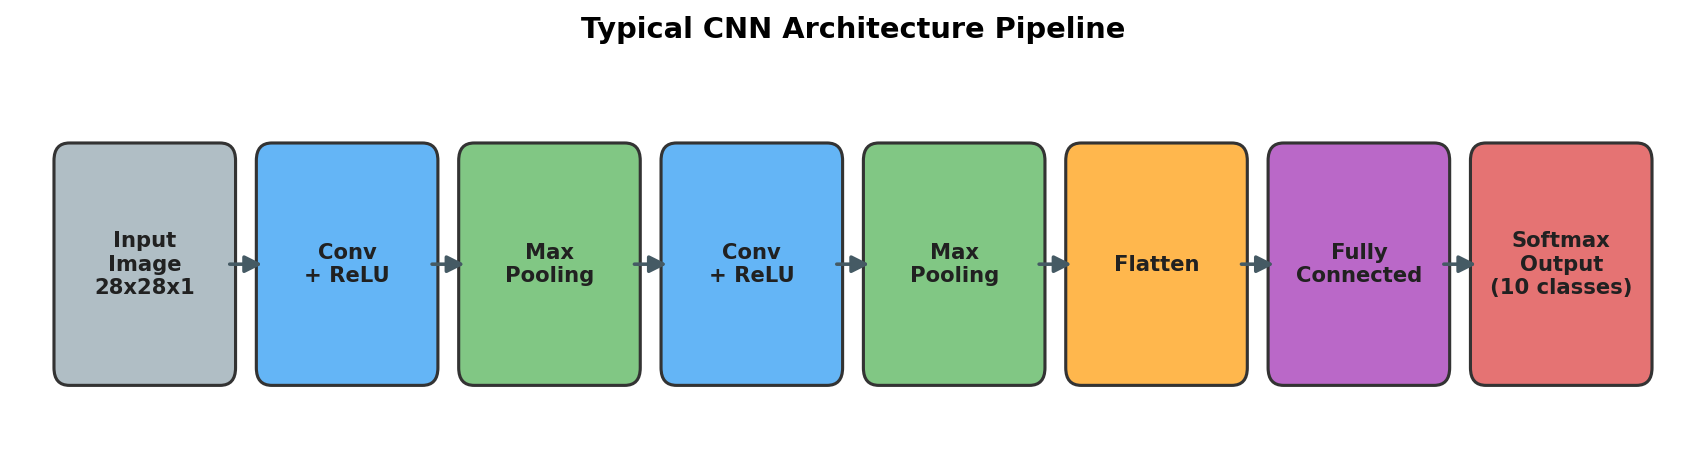

***Figure 1.** A typical CNN pipeline: Conv+ReLU and Pooling blocks repeated, then Flatten, Fully Connected, and Softmax output.*


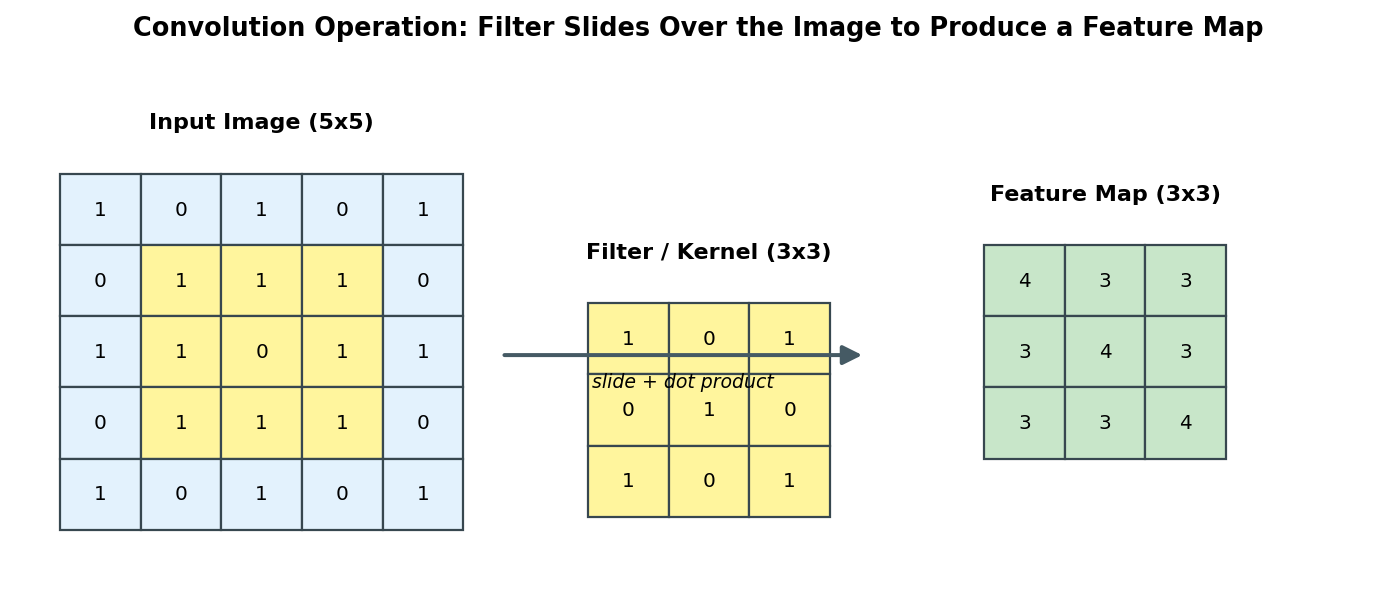

***Figure 2.** A 3x3 filter slides over the input image; at each position it computes a dot product with the underlying pixels to produce one value in the output feature map.*


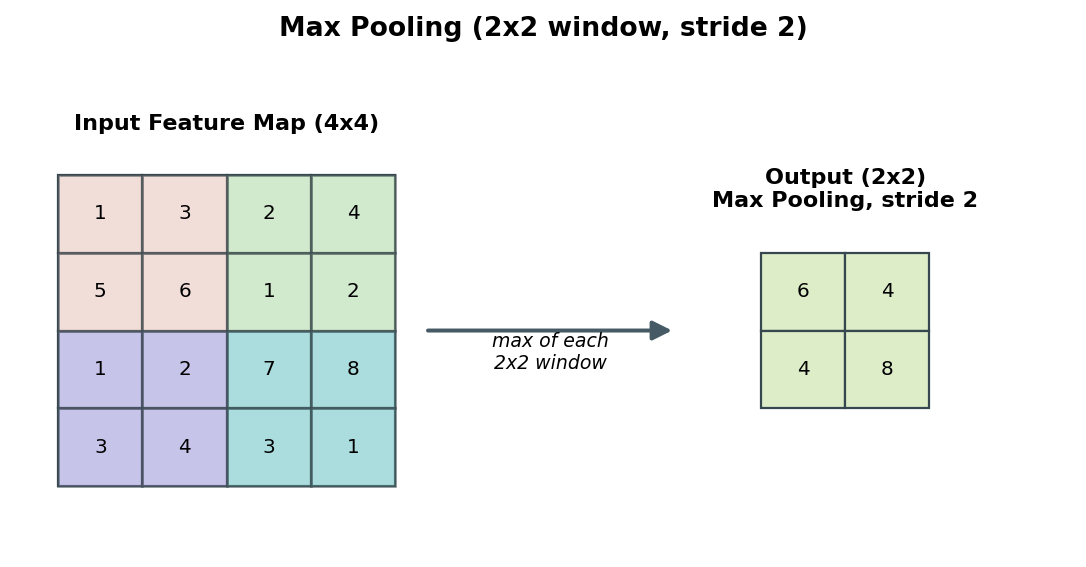

***Figure 3.** Max pooling with a 2x2 window and stride 2 — each window is reduced to its maximum value, halving the spatial dimensions.*


<a id="cnn-hyperparams"></a>


## 5. CNN Hyperparameters

Hyperparameters are settings chosen *before* training that control the model's architecture and learning process.

| Hyperparameter | Description | Effect on Performance |
|---|---|---|
| **Number of Filters** | How many filters each convolution layer learns. | More filters → richer features but more parameters and higher risk of overfitting/slower training. |
| **Kernel Size** | Spatial size of each filter (e.g., 3×3, 5×5). | Smaller kernels capture fine local details and are cheaper; larger kernels capture broader patterns but cost more. |
| **Padding** | Whether to pad the input with zeros ('same') or not ('valid'). | 'Same' padding preserves spatial dimensions; 'valid' shrinks the feature map, potentially losing border information. |
| **Stride** | Step size the filter moves across the input. | Larger stride → smaller output feature maps and less computation, but can miss fine detail. |
| **Pooling Size** | Size of the pooling window (e.g., 2×2). | Larger pooling windows reduce dimensions more aggressively, risking loss of important detail. |
| **Learning Rate** | Step size used to update weights during optimization. | Too high → unstable training/divergence; too low → very slow convergence or getting stuck. |
| **Batch Size** | Number of samples processed before updating weights. | Larger batches → more stable gradient estimates but more memory usage; smaller batches → noisier updates that can help generalization. |
| **Number of Epochs** | How many times the full training dataset is passed through the network. | Too few → underfitting; too many → overfitting (unless regularized/early-stopped). |


<a id="feature-extraction"></a>


## 6. Feature Extraction (Hierarchical Learning)

CNNs learn features in a **hierarchical** manner — each successive layer builds on the features detected by the previous one, moving from simple to complex:

- **Layer 1 (early layers):** Detects the simplest visual primitives — **edges** and **lines**.
- **Layer 2:** Combines edges/lines to detect **corners** and **curves**.
- **Layer 3:** Combines corners/curves to detect **shapes**.
- **Deep layers (later layers):** Combine shapes into high-level, semantic concepts such as **faces, cars, animals, buildings**, etc.

This hierarchical structure is what allows CNNs to automatically learn rich, meaningful representations directly from raw pixel data, without manual feature engineering.


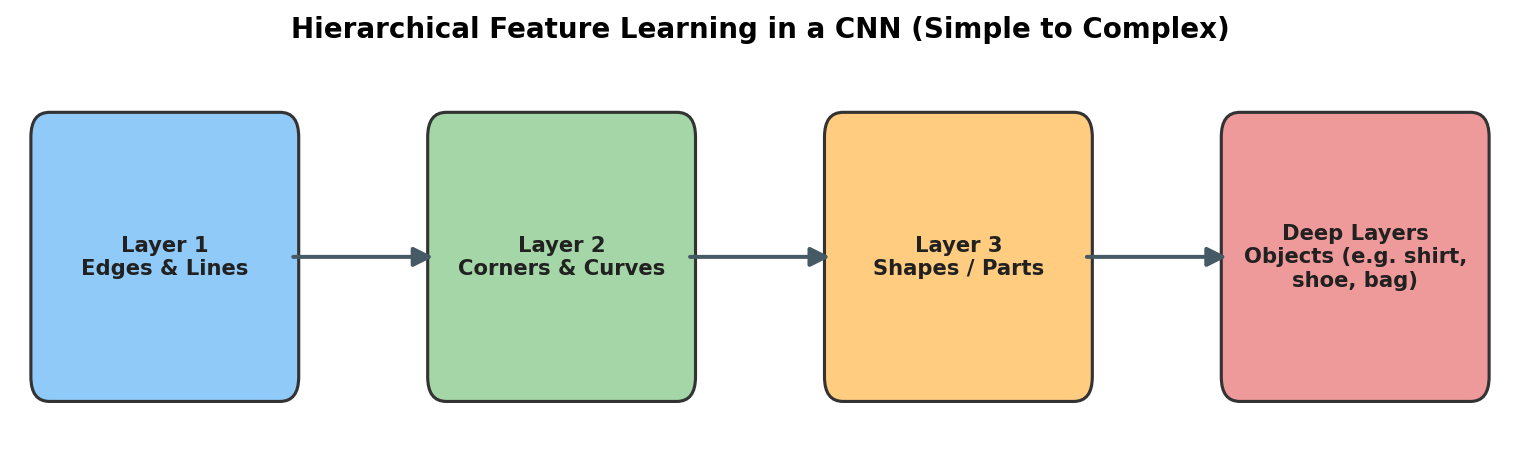

***Figure 4.** CNNs learn hierarchically — early layers detect edges, middle layers combine them into shapes, and deep layers recognize whole objects.*


<a id="popular-architectures"></a>


## 7. Popular CNN Architectures

| Architecture | Year | Key Contributions / Characteristics | Applications |
|---|---|---|---|
| **LeNet** | 1998 | First practical CNN; simple stack of conv + pooling layers. | Digit recognition (e.g., handwritten postal codes). |
| **AlexNet** | 2012 | Introduced ReLU activation, Dropout regularization, and GPU-accelerated training. Won the ImageNet 2012 competition, sparking the deep learning boom. | Large-scale image classification. |
| **VGGNet** | 2014 | Very deep architecture built using only small 3×3 convolutions stacked repeatedly, showing that depth improves performance. | Image classification, transfer learning backbone. |
| **GoogLeNet (Inception)** | 2014 | Introduced Inception modules that apply multiple filter sizes in parallel for efficient multi-scale feature extraction. | Image classification with reduced computational cost. |
| **ResNet** | 2015 | Introduced **residual learning** with **skip (shortcut) connections**, allowing training of extremely deep networks (100+ layers) by mitigating vanishing gradients. | Image classification, object detection backbones. |
| **DenseNet** | 2017 | Connects each layer to every other layer (feature reuse), improving gradient flow and parameter efficiency. | Image classification with fewer parameters. |
| **EfficientNet** | 2019 | Uses **compound scaling** (jointly scaling depth, width, and resolution) to achieve high accuracy with far fewer parameters. | State-of-the-art image classification with efficiency constraints. |


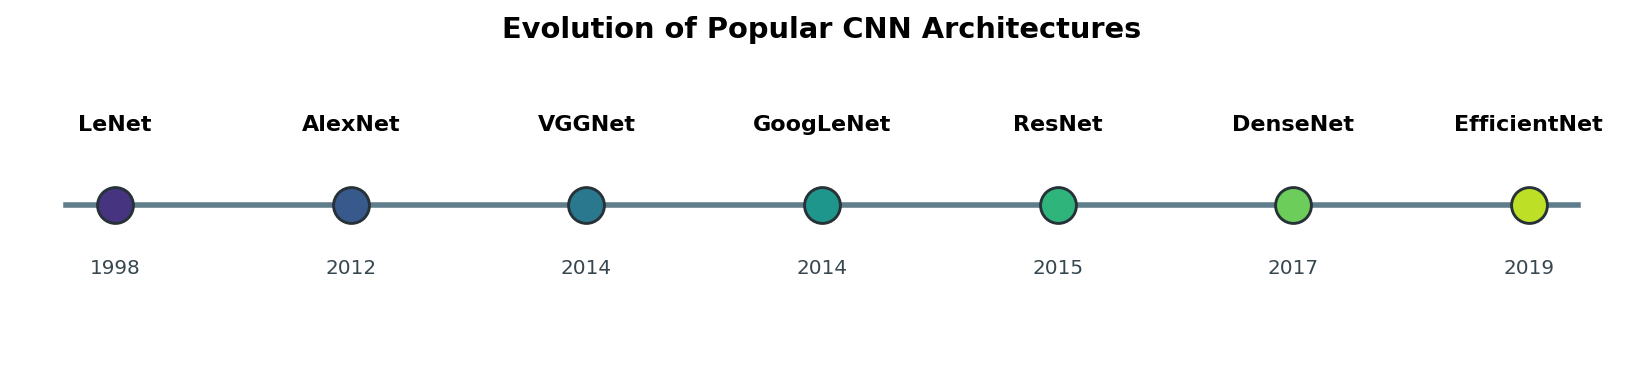

***Figure 5.** Timeline of landmark CNN architectures, from LeNet (1998) to EfficientNet (2019).*


<a id="part-b-practical"></a>


---
# Part B: Practical Assignment — Image Classification using CNN

**Dataset chosen:** Fashion-MNIST

The rest of this notebook implements the full practical assignment:
1. Data Preparation (load, normalize, augment, split, DataLoaders)
2. Build CNN Model (Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Flatten → FC → Output)
3. Train Model (Adam / SGD, different learning rates & batch sizes)
4. Model Evaluation (Accuracy, Precision, Recall, F1 Score, Confusion Matrix)
5. Visualization (loss/accuracy curves, confusion matrix, sample predictions, misclassified images)
6. Performance Comparison — CNN vs. ANN (with short report)

A fully connected **ANN baseline** is also trained alongside the **CNN** so the two can be directly compared, as required by the assignment.


<a id="setup-imports"></a>


## 1. Setup & Imports

In [ ]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from dataset import load_csv, train_val_test_split, FashionMNISTDataset, get_dataloaders, CLASS_NAMES
from models import ANN, CNN, count_parameters
from train import train_model
from evaluate import get_predictions, compute_metrics, find_misclassified
from visualize import plot_training_curves, plot_confusion_matrix, plot_sample_predictions, plot_misclassified

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


<a id="data-loading"></a>


## 2. Data Loading & Exploration

In [ ]:
CSV_PATH = "data/fashion_mnist.csv"

images, labels = load_csv(CSV_PATH)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel value range:", images.min(), "-", images.max())


In [ ]:
# Class distribution
label_counts = pd.Series(labels).value_counts().sort_index()
label_counts.index = CLASS_NAMES
print(label_counts)

plt.figure(figsize=(9,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Fashion-MNIST")
plt.tight_layout()
plt.show()


In [ ]:
# Sample images, one per class
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for cls in range(10):
    idx = np.where(labels == cls)[0][0]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()


<a id="data-preprocessing"></a>


## 3. Data Preprocessing

- Normalize pixel values to `[0, 1]`
- Stratified split: 75% train / 10% validation / 15% test
- Light augmentation on the training set only (random horizontal flip + small shift)

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(
    images, labels, val_size=0.10, test_size=0.15, seed=SEED
)
print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


<a id="pytorch-datasets"></a>


## 4. PyTorch Datasets & DataLoaders

In [ ]:
BATCH_SIZE = 64

train_loader, val_loader, test_loader = get_dataloaders(
    CSV_PATH, batch_size=BATCH_SIZE, val_size=0.10, test_size=0.15,
    augment_train=True, seed=SEED
)

xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape, " Batch labels:", yb.shape)


<a id="ann-model"></a>


## 5. ANN Model (Baseline)

A fully connected network with no convolutional layers — used to demonstrate why CNNs are better suited to image data.

In [ ]:
ann_model = ANN(num_classes=10)
print(ann_model)
print("Trainable parameters:", count_parameters(ann_model))


<a id="cnn-model"></a>


## 6. CNN Model

Architecture: `Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> FC -> Output`

In [ ]:
cnn_model = CNN(num_classes=10)
print(cnn_model)
print("Trainable parameters:", count_parameters(cnn_model))


<a id="training"></a>


## 7. Training

We train both models with the Adam optimizer as the primary configuration. Feel free to re-run
this cell with `optimizer_name="sgd"`, different `lr`, or different `EPOCHS` to compare, as required
by the assignment ("Experiment with Adam / SGD, different learning rates, different batch sizes").

In [ ]:
EPOCHS = 10
LR = 1e-3

print("Training ANN...")
ann_history, ann_time = train_model(ann_model, train_loader, val_loader, device,
                                     epochs=EPOCHS, lr=LR, optimizer_name="adam")


In [ ]:
print("Training CNN...")
cnn_history, cnn_time = train_model(cnn_model, train_loader, val_loader, device,
                                     epochs=EPOCHS, lr=LR, optimizer_name="adam")


### Optional: try SGD / different hyperparameters for comparison

In [ ]:
# Example of a second experiment (SGD, lower LR) - uncomment to run
# cnn_model_sgd = CNN(num_classes=10)
# sgd_history, sgd_time = train_model(cnn_model_sgd, train_loader, val_loader, device,
#                                      epochs=EPOCHS, lr=1e-2, optimizer_name="sgd")


<a id="evaluation-visualization"></a>


## 8 & 9. Evaluation and Visualization

In [ ]:
plot_training_curves(ann_history, title_prefix="ANN", save_path="outputs/ann_curves.png")
plot_training_curves(cnn_history, title_prefix="CNN", save_path="outputs/cnn_curves.png")


In [ ]:
ann_images, ann_true, ann_pred = get_predictions(ann_model, test_loader, device)
cnn_images, cnn_true, cnn_pred = get_predictions(cnn_model, test_loader, device)

ann_metrics = compute_metrics(ann_true, ann_pred)
cnn_metrics = compute_metrics(cnn_true, cnn_pred)

print("ANN  -> Acc: {:.4f}  Prec: {:.4f}  Rec: {:.4f}  F1: {:.4f}".format(
    ann_metrics["accuracy"], ann_metrics["precision"], ann_metrics["recall"], ann_metrics["f1"]))
print("CNN  -> Acc: {:.4f}  Prec: {:.4f}  Rec: {:.4f}  F1: {:.4f}".format(
    cnn_metrics["accuracy"], cnn_metrics["precision"], cnn_metrics["recall"], cnn_metrics["f1"]))


In [ ]:
plot_confusion_matrix(ann_metrics["confusion_matrix"], title="ANN Confusion Matrix",
                      save_path="outputs/ann_confusion_matrix.png")
plot_confusion_matrix(cnn_metrics["confusion_matrix"], title="CNN Confusion Matrix",
                      save_path="outputs/cnn_confusion_matrix.png")


In [ ]:
plot_sample_predictions(cnn_images, cnn_true, cnn_pred, n=10,
                        save_path="outputs/cnn_sample_predictions.png")


In [ ]:
wrong_idx = find_misclassified(cnn_images, cnn_true, cnn_pred, n=10)
plot_misclassified(cnn_images, cnn_true, cnn_pred, wrong_idx,
                    save_path="outputs/cnn_misclassified.png")


<a id="performance-comparison"></a>


## 10. ANN vs CNN Performance Comparison

In [ ]:
comparison = pd.DataFrame({
    "ANN": {
        "Accuracy": round(ann_metrics["accuracy"], 4),
        "Precision": round(ann_metrics["precision"], 4),
        "Recall": round(ann_metrics["recall"], 4),
        "F1 Score": round(ann_metrics["f1"], 4),
        "Training Time (s)": round(ann_time, 1),
        "Number of Parameters": count_parameters(ann_model),
    },
    "CNN": {
        "Accuracy": round(cnn_metrics["accuracy"], 4),
        "Precision": round(cnn_metrics["precision"], 4),
        "Recall": round(cnn_metrics["recall"], 4),
        "F1 Score": round(cnn_metrics["f1"], 4),
        "Training Time (s)": round(cnn_time, 1),
        "Number of Parameters": count_parameters(cnn_model),
    },
}).T

comparison.to_csv("outputs/ann_vs_cnn_comparison.csv")
comparison


<a id="save-model"></a>


## 11. Save the Trained CNN Model

In [ ]:
import os
os.makedirs("models", exist_ok=True)
torch.save(cnn_model.state_dict(), "models/cnn_fashion_mnist.pth")
print("Saved to models/cnn_fashion_mnist.pth")


<a id="report-discussion"></a>


## 12. Report / Discussion

**Why did the CNN outperform the ANN?**
The ANN flattens each 28×28 image into a 784-length vector immediately, so it throws away all
spatial relationships between neighboring pixels and has to learn every pattern independently at
every location in the image. The CNN instead uses convolutional filters with local receptive
fields and shared weights — the same edge/texture detector slides across the whole image — so it
needs far fewer parameters, generalizes better, and directly exploits the 2D spatial structure of
the image (an edge or fold pattern looks similar wherever it occurs in the picture).

**Impact of hyperparameters:**
- *Learning rate:* too high causes unstable/oscillating loss; too low slows convergence and can
  get stuck in poorer minima within the epoch budget.
- *Batch size:* larger batches give smoother gradient estimates and faster epochs (on GPU) but can
  generalize slightly worse than smaller batches with the same epoch count.
- *Optimizer:* Adam converges faster in early epochs than plain SGD; well-tuned SGD+momentum can
  match or exceed Adam's final accuracy but usually needs more epochs.
- *Number of filters / kernel size:* more filters increase capacity (and cost); a 3×3 kernel is a
  good default that keeps parameter count low while still capturing local patterns.

**Common causes of misclassification (see the misclassified-image grid above):**
- Visually similar classes — Shirt vs. T-shirt/top vs. Pullover vs. Coat are the most confused
  group in the confusion matrix, since they share similar silhouettes at 28×28 resolution.
- Low resolution (28×28 grayscale) removes fine texture detail that would otherwise disambiguate,
  e.g., a Shirt's collar/buttons from a Pullover.
- Sandals vs. Sneakers vs. Ankle boots can also be confused when the shoe silhouette is ambiguous
  or partially cropped.

*(Fill in exact numbers/observations from your own run above before submitting.)*
